# <center> Проект:      Прогнозирование кредитного риска

## Глава 1. Постановка задачи



    - Анализ факторов, влияющих на дефолт, и построение модели машинного обучения
    - Спрогнозировавать кредитный  риск в BNPL-транзакциях на основе финансовых и поведенческих характеристик клиентов.


Описание признаков 

`user_id`		Уникальный идентификатор пользователя

`age`		Возраст пользователя (18–59 лет)

`employment_type`		Наемный работник / самозанятый / студент / безработный

`monthly_income`		Ежемесячный доход в долларах США

`credit_score`		Стандартный кредитный рейтинг (300–850)

`purchase_amount`		Сумма транзакции BNPL в долларах США

`product_category`		Электроника, мода, спорт, дом, красота

`bnpl_installments`		Количество выплат (3, 6, 9, 12)

`repayment_delay_days`		Дни просрочки (0–33)

`missed_payments`		Общее количество просроченных платежей (0–7)

`default_flag`		Target: 1 = не оплачено, 0 = оплачено ✅

`app_usage_frequency`		Приложение открывается раз в неделю

`location`		Страна (США, Индия, Великобритания, Германия, Канада, Австралия)

`transaction_date`		Дата покупки (ГГГГ-ММ-ДД)

`debt_to_income_ratio`		Коэффициент DTI (отношение ежемесячного долга к ежемесячному доходу)

`risk_score`		Комплексная оценка риска (0–398) — чем выше, тем выше риск

`customer_segment`		Низкий риск / Средний риск / Высокий риск

## Глава 2. Импорт библиотек  и загрузка данных

### 2.1. Импорт библиотек

In [293]:
# Импорт библиотек 
# Стандартные библиотеки
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Scikit-learn
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
)
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,     
    f1_score,
)
from scipy.stats import chi2_contingency
from scipy.stats import kruskal
from sklearn.calibration import calibration_curve

import xgboost as xgb

warnings.filterwarnings('ignore')


### 2.2. Чтение данных

In [294]:
# загрузка данных
data = pd.read_csv('Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')

# Вывод первых 5 строк
data.head()

,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


## Глава 3. Очистка и предобработка


### 3.1. Просмотр основных  статистических данных


In [295]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               10345 non-null  int64  
 1   age                   10345 non-null  int64  
 2   employment_type       10345 non-null  object 
 3   monthly_income        10345 non-null  float64
 4   credit_score          10345 non-null  int64  
 5   purchase_amount       10345 non-null  float64
 6   product_category      10345 non-null  object 
 7   bnpl_installments     10345 non-null  int64  
 8   repayment_delay_days  10345 non-null  int64  
 9   missed_payments       10345 non-null  int64  
 10  default_flag          10345 non-null  int64  
 11  app_usage_frequency   10345 non-null  float64
 12  location              10345 non-null  object 
 13  transaction_date      10345 non-null  object 
 14  debt_to_income_ratio  10345 non-null  float64
 15  risk_score         

In [296]:
# описательный анализ для числовых  признаков 
data.describe()

,user_id,age,monthly_income,credit_score,purchase_amount,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,debt_to_income_ratio,risk_score
count,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000
mean,5173.000000,38.559884,35053.381898,448.176124,3979.402721,7.477525,8.742774,1.015950,0.390527,5.524101,0.181071,198.534094
std,2986.488601,12.131789,27084.517277,136.518332,1500.828483,3.362867,6.781849,0.996726,0.487892,2.590364,0.124887,67.541384
min,1.000000,18.000000,5000.000000,300.000000,100.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000811,0.000000
25%,2587.000000,28.000000,12207.020000,332.000000,2990.720000,3.000000,2.000000,0.000000,0.000000,3.300000,0.080187,153.600000
50%,5173.000000,39.000000,23800.520000,403.000000,5000.000000,9.000000,9.000000,1.000000,0.000000,5.550000,0.138263,202.800000
75%,7759.000000,49.000000,55276.930000,547.000000,5000.000000,9.000000,14.000000,2.000000,1.000000,7.750000,0.268300,250.800000
max,10345.000000,59.000000,145767.120000,850.000000,5000.000000,12.000000,33.000000,7.000000,1.000000,10.000000,0.723460,398.000000


In [297]:
# Описательная статистика для категориальныъ  признаков 
data.describe(include='object')

,employment_type,product_category,location,transaction_date,customer_segment
count,10345,10345,10345,10345,10345
unique,4,5,6,365,3
top,Salaried,Fashion,Germany,2024-08-15,High Risk
freq,2632,2166,1760,42,7569


**Вывод по описательной статистике**

Проведённый анализ структуры и основных статистических показателей датасета позволил составить целостное представление о доступных данных и выявить ключевые особенности, которые необходимо учесть при построении модели.

`1. Структура и качество данных`

Датасет изначально содержит 17 признаков для 10 345 уникальных BNPL-транзакций. Пропуски и явные дубликаты отсутствуют, что упрощает этап предобработки. Признак transaction_date требует приведения к формату даты и извлечения временных компонентов (месяц, день недели, выходной/будний).

`2. Профиль типичного заёмщика`

Средний возраст пользователя составляет 38 лет (от 18 до 59). 
Наблюдается значительный разброс по доходу: медианный доход около 23 800 ,со стандартным отклонением ≈27 000,  указывает на присутствие как низкодоходных (5000), так и высокодоходных (145 000+) клиентов. 
Это разнообразие может быть полезным для сегментации риска.

`3. Кредитное качество и платёжное поведение`

Обращает на себя внимание наличие клиентов с кредитным рейтингом ниже общепринятого минимума в 300 баллов, что свидетельствует о присутствии высокорискованных заёмщиков. Средний чек покупки составляет около $4 000 и в большинстве случаев разбивается на 6–9 платежей. Средняя просрочка составляет 8 дней, однако распределение скошено: большинство клиентов имеет 0–1 пропуск, но есть единичные случаи с 7 пропусками, что формирует длинный «тяжёлый хвост». Частота использования приложения (≈5 раз в неделю) не демонстрирует очевидной связи с дефолтностью(это можем более лучше рассмотреть при дальнейшем анализе)

`4. Категориальный портрет`

Среди типов занятости преобладают наёмные сотрудники, однако доля дефолтов выше у студентов и безработных, что соответствует ожиданиям. Самая популярная категория товаров — «Мода» — одновременно характеризуется повышенной долей дефолтов, что может указывать на импульсный характер покупок. Географически большинство клиентов происходит из Германии, которая вместе с Великобританией и Австралией входит в зону повышенного риска. 

`5. Временны́е особенности`
Признак transaction_date содержит информацию о дате покупки. Пиковое количество транзакций приходится на середину августа 2024 года, что может быть связано с сезонными распродажами.




### 3.2. Предобработка данных

In [298]:
# наличие пропусков в данных
if data.isnull().sum().sum()==0:
    print('Датасет  не имеет в себе пропусков')
else:
    print(f'Датасет имеет в себе {data.isnull().sum().sum()} пропусков, необходима очистка ')
    

Датасет  не имеет в себе пропусков


In [299]:
# наличие дубликатов 
if data.duplicated().sum().sum()==0:
    print('Датасет не имеет в себе пропусков')
else:
    print('Датасет имеет в себе дубликаты необходима очистка')
    print(f'Очищаем данные от {data.duplicated().sum().sum()} дубликатов...')
    data= data.drop_duplicates()
    print('Датасет очищен')

Датасет не имеет в себе пропусков


In [300]:
# наличие выбросов
#  Список числовых колонок 
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

outlier_stats = []

for i, col in enumerate(numeric_cols):
    # IQR метод
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_pct = len(outliers) / len(data) * 100
    outlier_stats.append((col, len(outliers), outlier_pct))

# Вывод статистики по выбросам
print("\nСтатистика выбросов по признакам")
for col, count, pct in outlier_stats:
    print(f"{col:17s}: {count:4d} ({pct:5.2f}%)")


Статистика выбросов по признакам
user_id          :    0 ( 0.00%)
age              :    0 ( 0.00%)
monthly_income   :   25 ( 0.24%)
credit_score     :    0 ( 0.00%)
purchase_amount  :    0 ( 0.00%)
bnpl_installments:    0 ( 0.00%)
repayment_delay_days:    1 ( 0.01%)
missed_payments  :    8 ( 0.08%)
default_flag     :    0 ( 0.00%)
app_usage_frequency:    0 ( 0.00%)
debt_to_income_ratio:   57 ( 0.55%)
risk_score       :   31 ( 0.30%)


In [301]:
#  Признаки из даты
data['transaction_date'] = pd.to_datetime(data['transaction_date'])
data['order_month'] = data['transaction_date'].dt.month
data['order_dayofweek'] = data['transaction_date'].dt.dayofweek  # 0=пн, 6=вс
data['is_weekend'] = (data['order_dayofweek'] >= 5).astype(int)
data['order_year'] = data['transaction_date'].dt.year

data= data.drop('transaction_date', axis=1)

In [302]:
# дополниельно, Проверка есть ли повторяющиеся покупки клиентов 
len(data['user_id'].unique())
# удаление признака user_id из-за неинформативности 
data= data.drop('user_id', axis=1)

**Вывод по предварительной обработки данных:**

Проведённый этап очистки и преобразования исходного датасета подтверждает его высокую готовность к анализу и моделированию.

`Качество данных.` Датасет не содержит пропущенных значений и полных дубликатов. Это указывает на то, что исходные данные были хорошо структурированы и не требуют затратных процедур восстановления или удаления записей, что позволяет сразу перейти к исследовательскому анализу.

`Выбросы.` В числовых признаках обнаружено незначительное количество выбросов (менее 1% по каждому из них). Их природа и степень влияния будут более детально изучены на этапе визуализации. Учитывая, что в дальнейшем планируется использование ансамблевых древовидных моделей, которые устойчивы к экстремальным значениям, маловероятно, что эти выбросы потребуют жёсткой очистки.

`Преобразование даты.` Из исходного признака transaction_date были успешно выделены новые временные компоненты: месяц, день недели, флаг выходного дня и год совершения транзакции. Эти признаки потенциально позволяют учесть сезонные паттерны потребительского поведения, различия в платёжной дисциплине в будние и выходные дни, а также долгосрочные годовые тренды, если таковые будут выявлены.

`Признак user_id`  не несет в себе информативности (все значения являются уникальными), и он подлежит очистке 

## Глава 4. Разведывательный анализ (EDA)

###  4.1. Визуализация данных

In [303]:
# создаем папку для сохранения графиков 
image_dir = "images"
if not os.path.exists(image_dir):
    os.makedirs(image_dir)
    print(f"Папка {image_dir} создана")
else:
    print(f"Использую существующую папку: {image_dir}")



Использую существующую папку: images


#### Визуализация выбросов


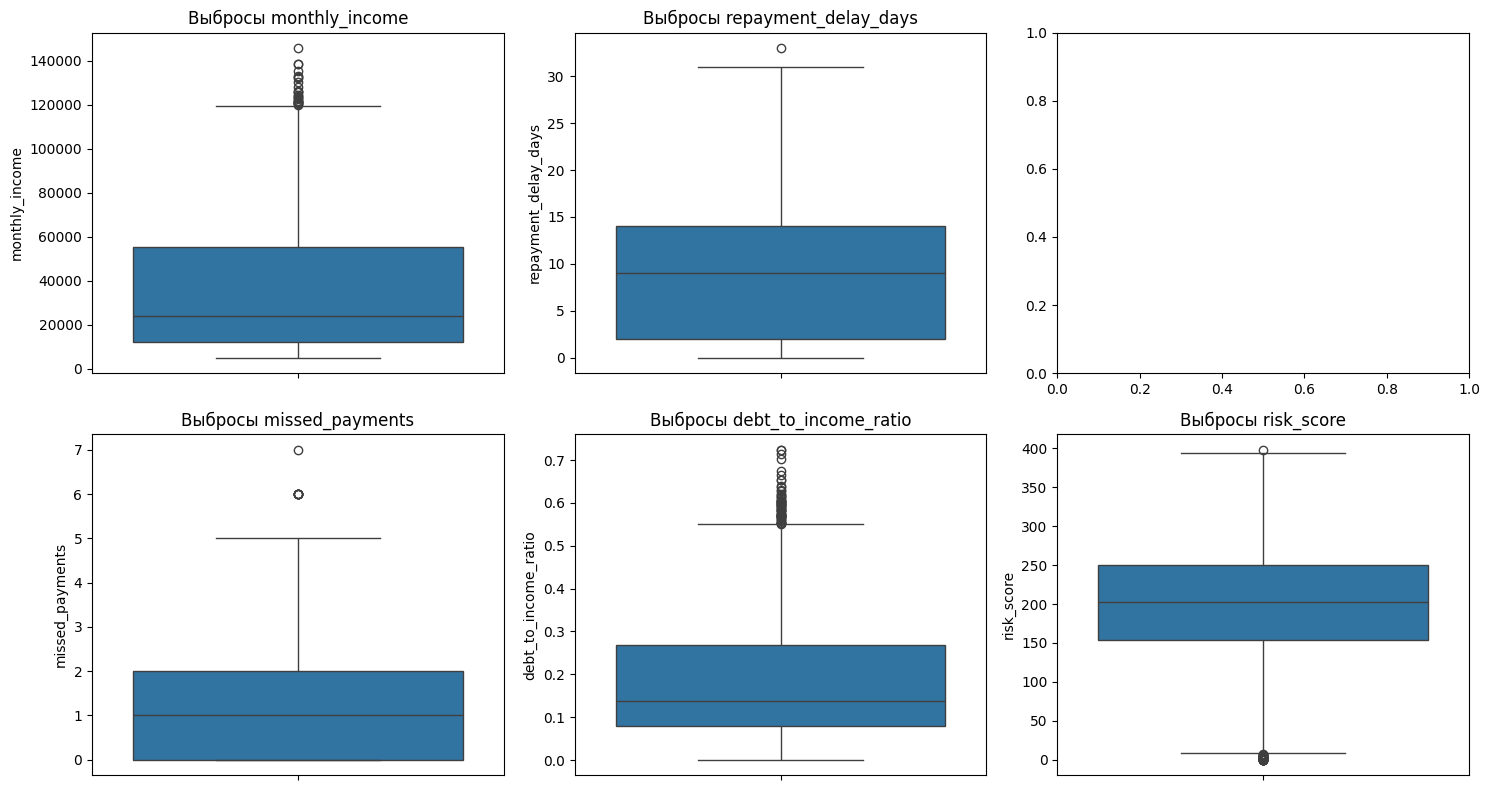

In [304]:
# Визуализация выбросов 

fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxplot(y=data['monthly_income'], ax=axes[0,0])
axes[0,0].set_title('Выбросы monthly_income')

sns.boxplot(y=data['repayment_delay_days'], ax=axes[0,1])
axes[0,1].set_title('Выбросы repayment_delay_days')

sns.boxplot(y=data['missed_payments'], ax=axes[1,0])
axes[1,0].set_title('Выбросы missed_payments')

sns.boxplot(y=data['debt_to_income_ratio'], ax=axes[1,1])
axes[1,1].set_title('Выбросы debt_to_income_ratio')


sns.boxplot(y=data['risk_score'], ax=axes[1,2])
axes[1,2].set_title('Выбросы risk_score')

plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'boxplots_outliers.png'), dpi=300, bbox_inches='tight')
plt.show()

**Вывод по визуализации выбросов в признаках**

`Доля  выбросов` в датасете не превышает 1% от общего числа наблюдений, а сами значения не являются аномально оторванными от основного распределения — скорее, они отражают естественную вариабельность данных (например, клиенты с очень высоким доходом или длительными просрочками).

Поскольку в качестве базовых алгоритмов выбраны `ансамблевые методы на основе деревьев решений` (Random Forest, Gradient Boosting, XGBoost), которые по своей природе устойчивы к экстремальным значениям, принято решение не удалять и не ограничивать выбросы.

Таким образом, `сохранение выбросов в данных` позволит модели учитывать реальные «крайние» случаи поведения клиентов, не прибегая к искусственному искажению выборки

#### Анализ целевой переменной

Доля дефолтов: 39.05%


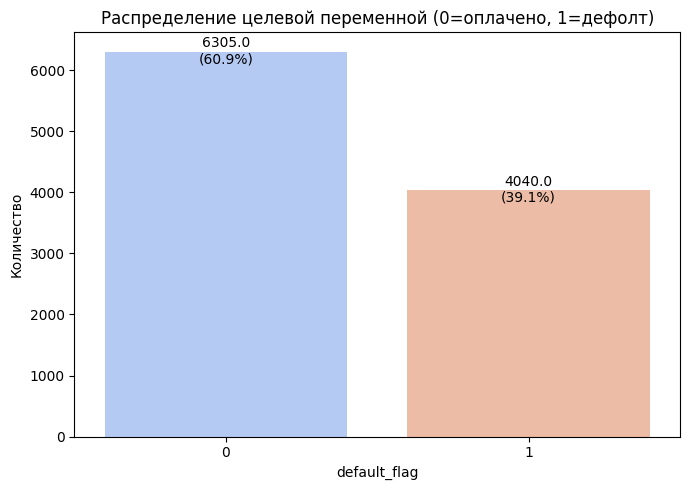

In [305]:
# Анализ целевой переменной 
default_rate = data['default_flag'].mean()
print(f'Доля дефолтов: {default_rate:.2%}')

plt.figure(figsize=(7,5))
ax = sns.countplot(data=data, x='default_flag', palette='coolwarm')
plt.title('Распределение целевой переменной (0=оплачено, 1=дефолт)')
plt.xlabel('default_flag')
plt.ylabel('Количество')

total = len(data)
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2., height,
            f'{height}\n({height/total:.1%})',
            ha='center', va='center')

plt.tight_layout()
plt.show()

Вывод по визуальному распределению целевой переменной 

- `Несбалансированность классов:` Выявленный дисбаланс классов (около 39% дефолтов) требует обязательного использования стратифицированного разбиения и специальных метрик (PR-AUC, F1-score), чтобы сохранить пропорции классов в обоих выборках.

- `Бизнес‑контекст:` почти 40% BNPL‑транзакций заканчиваются невозвратом. Это очень высокий показатель, который свидетельствует либо о специфике продукта, либо о недостаточно строгом скоринге при выдаче.

####  Визуализация категориальных признаков vs целевой переменной 

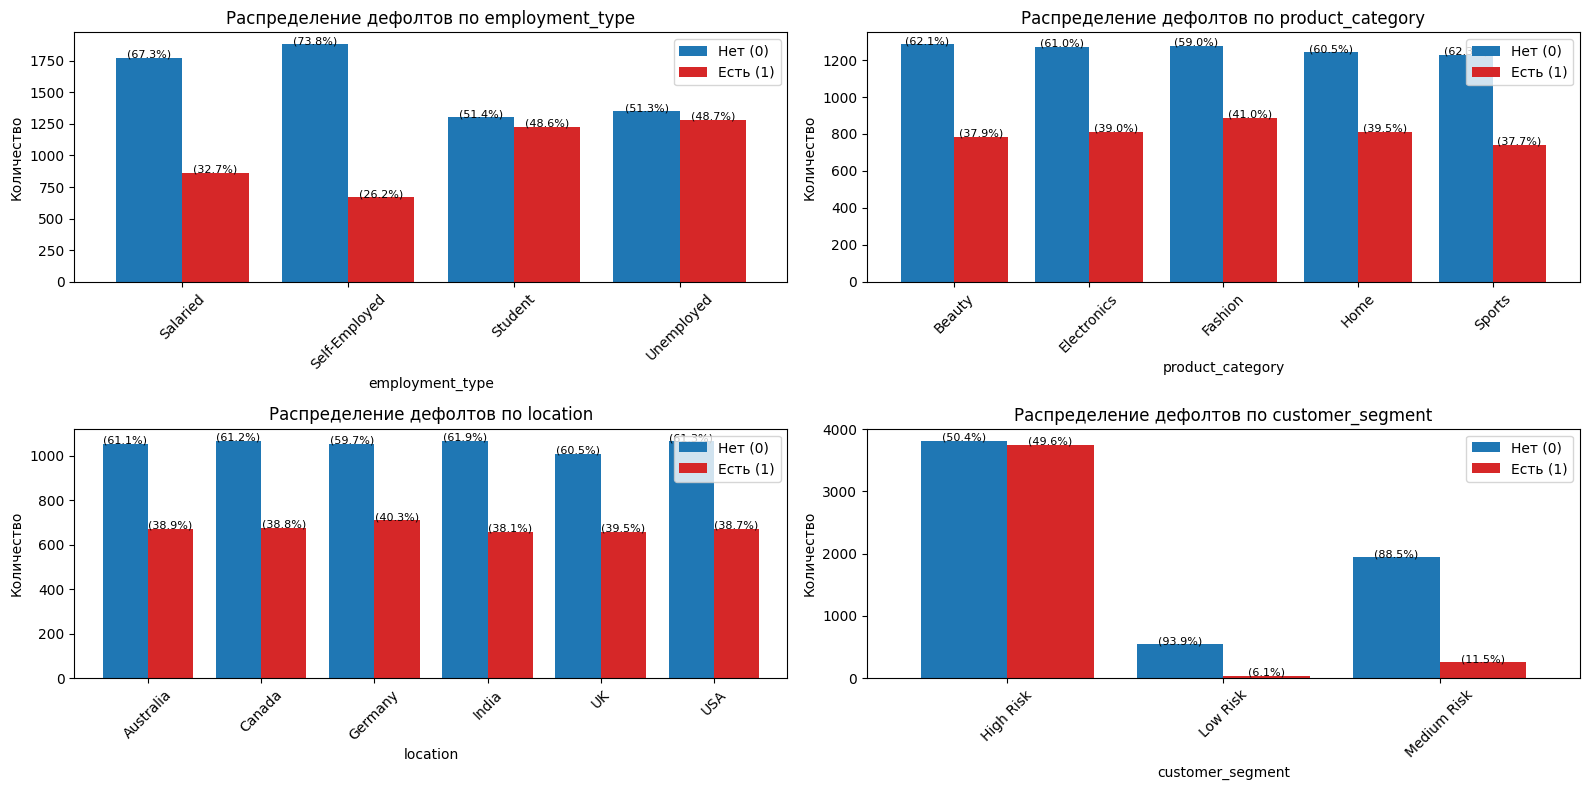

In [306]:
# Категориальные признаки vs default_flag
# строим фигуру 2х2
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
# для удобства превращаем массив 2*2 на одномерный списак ( удобно для цикла )
axes = axes.flatten()
# выбираем цвета 
palette = ['#1f77b4', '#d62728']  # синий, красный

# выбираем категориальные признаки которые необходимо проанализирровать 
cat_cols = ['employment_type', 'product_category', 'location', 'customer_segment']

for i, col in enumerate(cat_cols):
    ''' группипуем данные по признаку дефолта, 
    после считаем среднее значение и сортируем по убыванию,
    далее превращаем данные в датафрейм и строим фигуры 
    '''
    ax = axes[i]
    counts = data.groupby([col, 'default_flag']).size().unstack()
    counts.plot(kind='bar', ax=ax, color=palette, width=0.8)
    ax.set_title(f'Распределение дефолтов по {col}')
    ax.set_ylabel('Количество')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(['Нет (0)', 'Есть (1)'])
    
    # Добавляем подписи процентов внутри категории
    totals = counts.sum(axis=1)
    for j, (cat_name, row) in enumerate(counts.iterrows()):
        for def_val in [0, 1]:
            if def_val in row.index:
                count = row[def_val]
                if count > 0:
                    # Координата x патча: j - 0.2 для 0, j + 0.2 для 1 (при width=0.8)
                    x_pos = j - 0.2 if def_val == 0 else j + 0.2
                    ax.text(x_pos, count + 1, f'({count/totals[cat_name]:.1%})',
                            ha='center', fontsize=8)
plt.tight_layout()
plt.show()

**Вывод по визуализации распределения категориальных признаков к признаку дефолта**

`Employment_type:` Самый высокий дефолт у категории **Безработные ** и **студенты**, это логично. Безработным и студентам сложнее выплачивать заемы. 

`Location:` и `Product_category:`Разница в значениях минимальна. Далее при статистичемких тестах будет принято решение оставить или убрать данный признаки.  

`Customer_segment:` Ожидаемо, доля дефолтов растёт от Low Risk → Medium Risk → High Risk.

####  Визуализация Числовых  признаков vs целевой переменной 

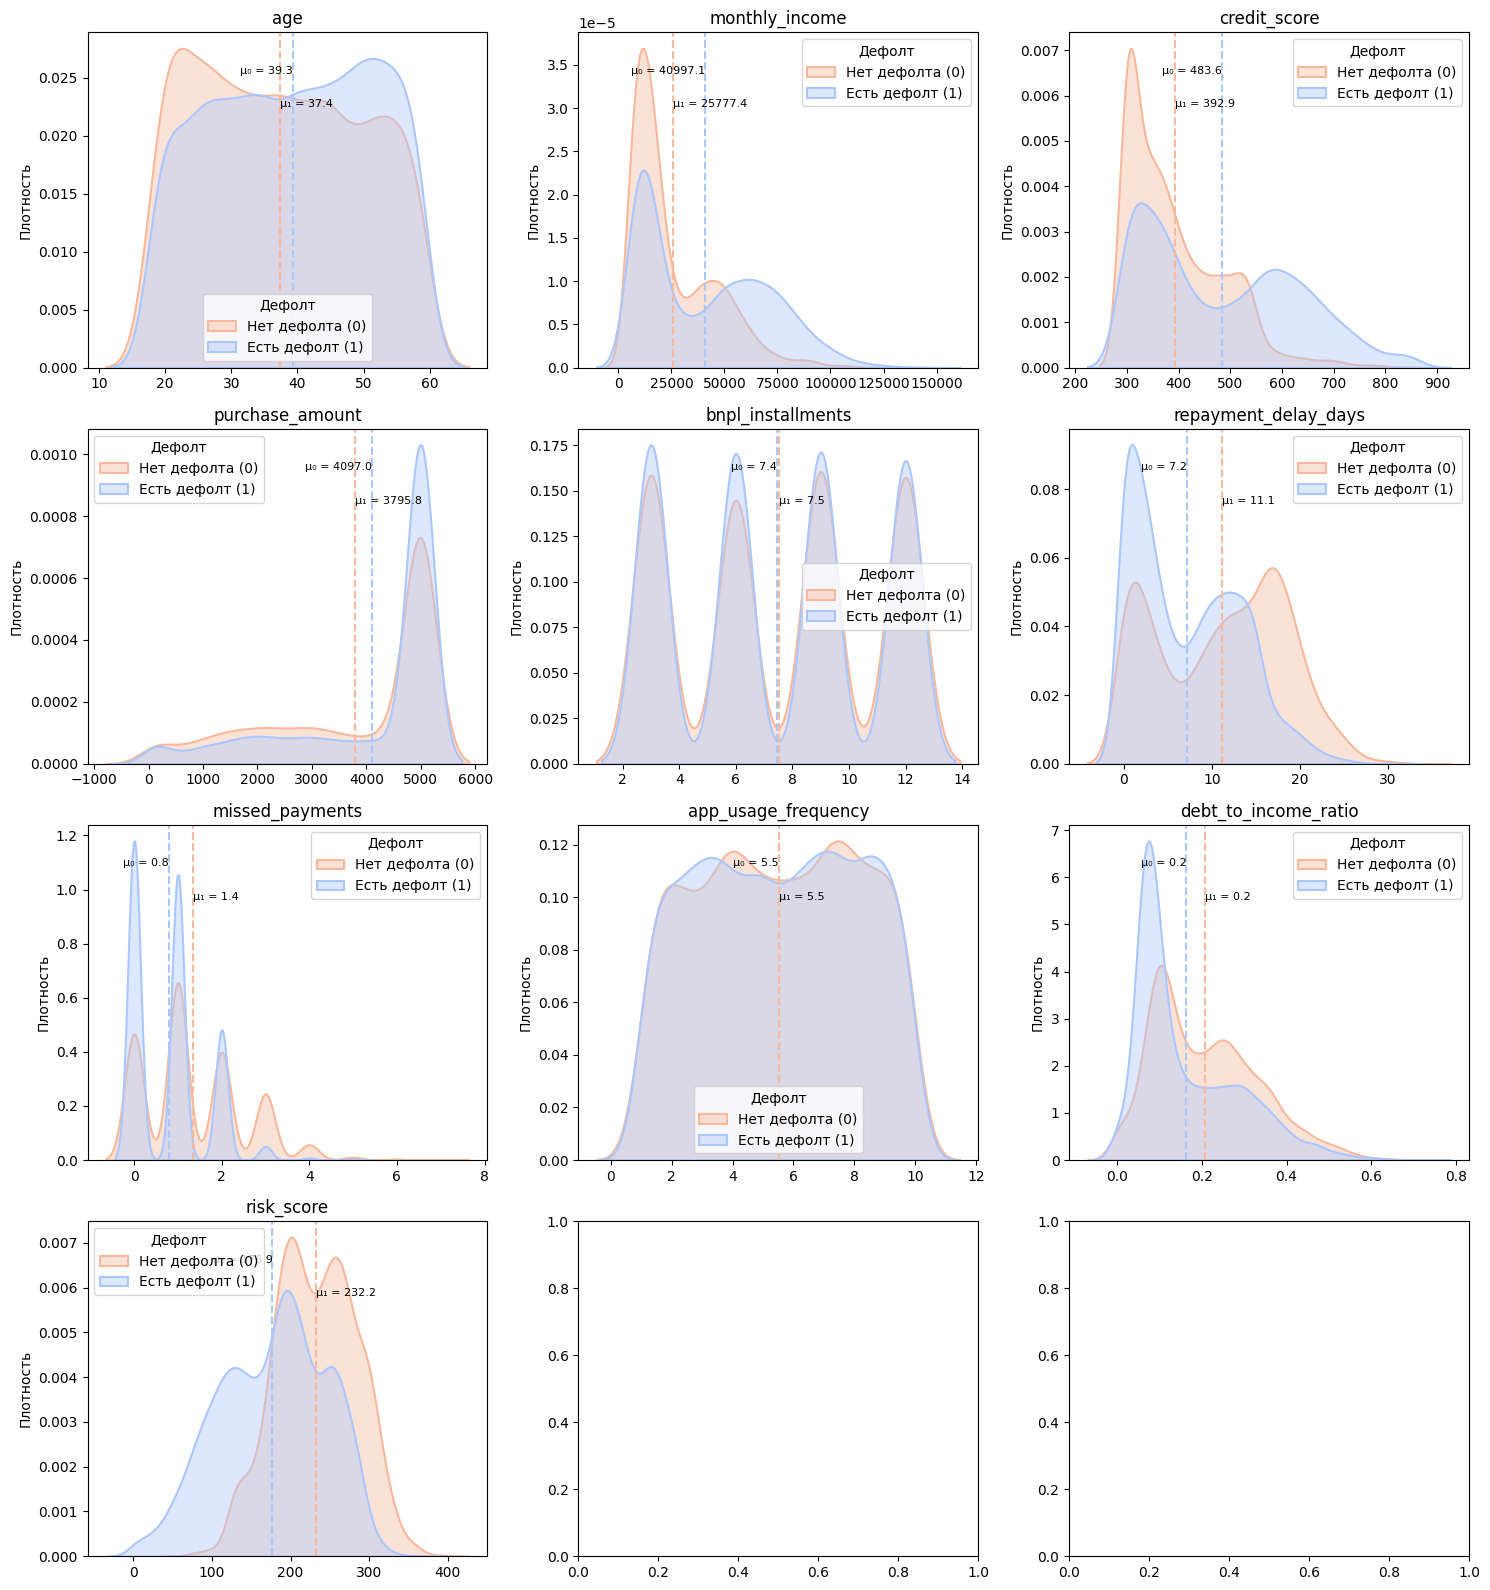

In [307]:
# получение списка числовых признаков и исключение из них целевого признака 
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
new_numeric_cols = [c for c in numeric_cols if c != 'default_flag']

# Создаем динамическую сетку : если признаков 12, получится 4 строки по 3 столбца.
n_cols = 3
n_rows = math.ceil(len(new_numeric_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

#  превращает двумерный массив осей в одномерный список, чтобы к нему было удобно обращаться по индекс
axes = axes.flatten()

# фиксируем цвет на граффиках, 
# первый для класса 0 (оплачено), второй для класса 1 (дефолт). 
# Они будут использоваться для вертикальных линий средних значений.
palette = sns.color_palette('coolwarm', 2)
color0, color1 = palette[0], palette[1]

# создаем цикл для построения графиков 
for idx, col in enumerate(new_numeric_cols):
    ax = axes[idx]

    # KDE с заливкой 
    sns.kdeplot(
        data=data, x=col, hue='default_flag',
        fill=True, common_norm=False,    # ключевой момент: каждая кривая интегрируется в 1
        palette='coolwarm', ax=ax, alpha=0.4, linewidth=1.5
    )

    # Вычисление средних для каждого класса
    mean0 = data.loc[data['default_flag'] == 0, col].mean()
    mean1 = data.loc[data['default_flag'] == 1, col].mean()

    # Вертикальные линии средних
    ax.axvline(mean0, color=color0, linestyle='--', linewidth=1.5)
    ax.axvline(mean1, color=color1, linestyle='--', linewidth=1.5)

    # Текстовые метки на линиях средних 
    ax.text(mean0, 0.9, f'μ₀ = {mean0:.1f}', transform=ax.get_xaxis_transform(), fontsize=8, ha='right', va='top')
    ax.text(mean1, 0.8, f'μ₁ = {mean1:.1f}', transform=ax.get_xaxis_transform(), fontsize=8, ha='left', va='top')

    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('Плотность')
    # убираем дублирование в легенде, оставляем только названия классов
    handles, labels = ax.get_legend_handles_labels()
    # даем подпись для обозначени цвета (дефолт или нет)
    ax.legend(title='Дефолт', labels=['Нет дефолта (0)', 'Есть дефолт (1)'])



plt.tight_layout()
plt.show()


##### Краткий вывод


`age` - Средний возраст “хороших” клиентов (39.3 года) выше, чем “плохих” (37.4). Различие небольшое, но указывает, что более молодые заёмщики чуть более рискованны. 

`monthly_income` cредний доход дефолтных клиентов (25 777 USD) существенно ниже, чем у надёжных (40 997 USD). Распределение дефолтников сильнее скошено влево, с основной массой до 20 000 USD, тогда как у неплательщиков доходы распределены более равномерно вплоть до 80 000 USD. Это сильный предиктор: чем ниже доход, тем выше риск.

`credit_score` Распределение дефолтных клиентов смещено влево (среднее ~393 против ~484 у надёжных).Высокий кредитный рейтинг — сильный защитный фактор. Пик в районе 500–700 характерен только для неплательщиков.Признак обладает высокой предсказательной силой.

`purchase_amount`- разница средних невелика: ~3796 у дефолтников против ~4097 у надёжных. На гистограммах видно, что у дефолтников чуть выше доля покупок в нижнем ценовом сегменте (до 2000 USD). Крупные покупки (близкие к 5000 USD) примерно одинаковы в обоих классах. Признак слабо разделяет классы.

`repayment_delay_days и missed_payments` - у дефолтных клиентов средняя задержка (11.1 дня) и количество пропусков (1.35) заметно вышу. Распределения имеют длинные правые хвосты, указывающие на экстремальные случаи. Вывод: поведенческие признаки напрямую связаны с будущим дефолтом, очень важны.

`bnpl_installments и app_usage_frequency` - распределения практически идентичны для обоих классов. Корреляция с дефолтом близка к нулю. Вывод: эти признаки можно исключить..

`debt_to_income_ratio`- У дефолтников среднее DTI 0.208 против 0.164 у надёжных. Плотность дефолтного класса немного смещена вправо, особенно в области 0.3–0.5. Высокая долговая нагрузка ожидаемо повышает риск.

`risk_score` - очень сильное разделение: средний риск у дефолтников ~232, у надёжных ~177. Распределения чётко разнесены. Признак имеет высокую предсказательную силу, но не может быть использован в реальной скоринговой модели из-за утечки данных (вероятно, он вычислен с учётом факта дефолта).


#### Корреляционная матрица


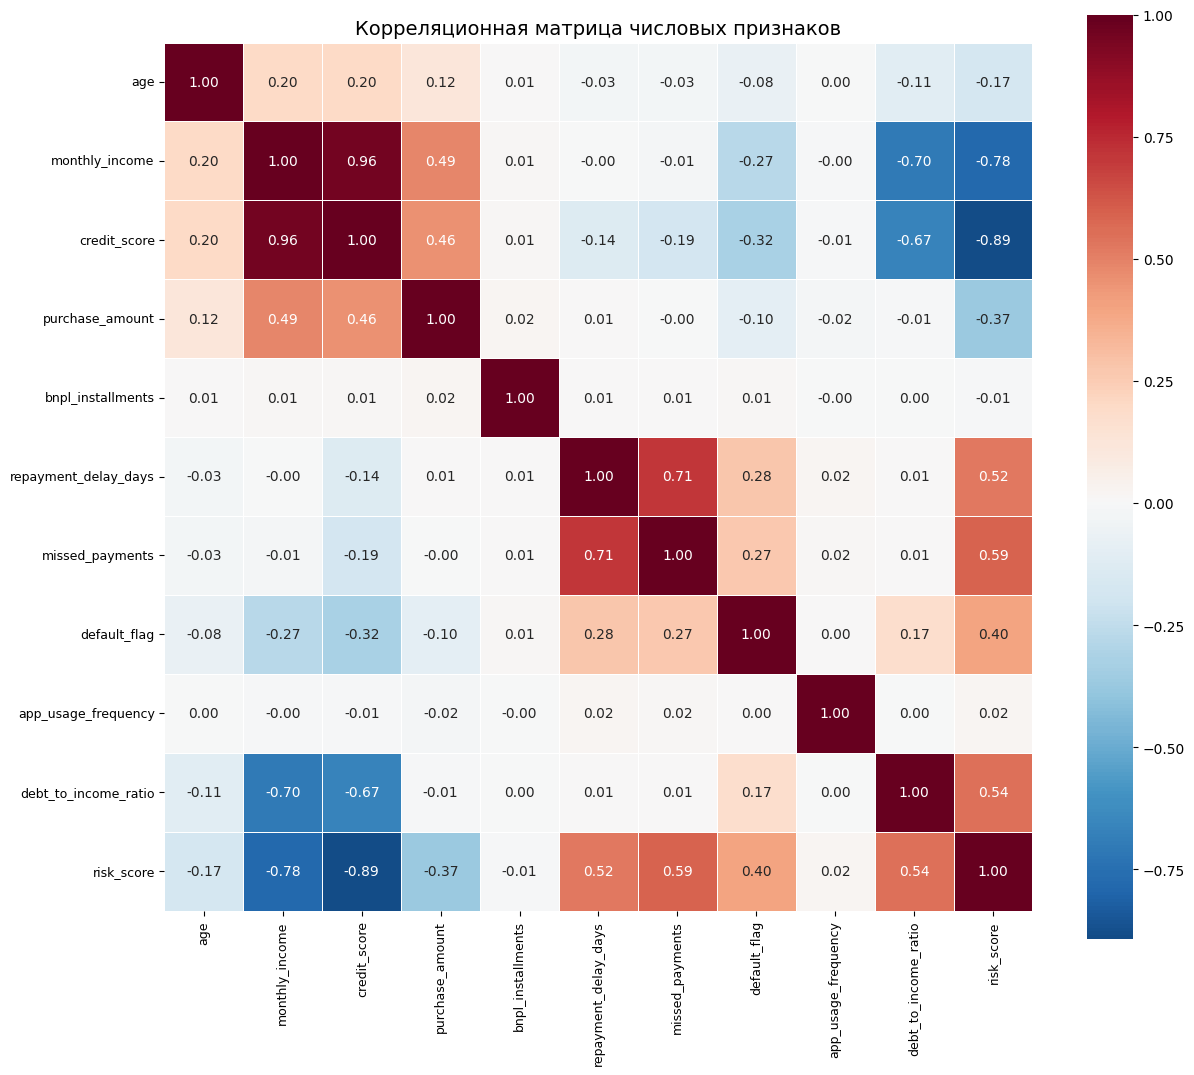

Корреляция признаков с default_flag:
 risk_score              0.399379
repayment_delay_days    0.283209
missed_payments         0.272267
debt_to_income_ratio    0.172947
bnpl_installments       0.012244
app_usage_frequency     0.003864
age                    -0.075702
purchase_amount        -0.097912
monthly_income         -0.274163
credit_score           -0.324238
Name: default_flag, dtype: float64


In [308]:
# Корреляционная матрица

corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, annot_kws={"size": 10})
plt.title('Корреляционная матрица числовых признаков', fontsize=14)
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.show()

# Корреляция с целевой переменной
target_corr = corr_matrix['default_flag'].drop('default_flag').sort_values(ascending=False)
print("Корреляция признаков с default_flag:\n", target_corr)

Сильная положительная корреляция (риск растёт с увеличением признака):

1. `risk_score (0.399)` – искусственный композитный признак, сильно связан с дефолтом (но не применим в реальной модели из-за утечки данных).

2. `repayment_delay_days (0.283)` и `missed_payments (0.272)` – чем дольше задержка, тем выше риск.

3. `debt_to_income_ratio (0.173)` – долговая нагрузка увеличивает вероятность дефолта.


Сильная отрицательная корреляция (риск снижается с увеличением признака):

1. `credit_score (-0.324)` – высокий кредитный рейтинг – защитный фактор.

2. `monthly_income (-0.274)` – высокий доход снижает риск.

3. `purchase_amount (-0.098)` – очень слабая отрицательная связь (почти нейтрально).

4. `age (-0.076)` – тоже слабая, но старшие клиенты чуть надёжнее.


Практически нулевая корреляция (можно исключить из модели):

1. bnpl_installments (0.012) и app_usage_frequency (0.004)


Практические выводы:

Признаки с корреляцией >|0.1| (по модулю) стоит оставить в модели (особенно credit_score, monthly_income, repayment_delay_days, missed_payments, debt_to_income_ratio).

Признаки с почти нулевой корреляцией (bnpl_installments, app_usage_frequency) можно удалить без потери качества.

Высокая корреляция risk_score с дефолтом (0.40) подтверждает, что этот признак хорошо предсказывает, но он обычно вычисляется с использованием информации о дефолте и не должен использоваться в реальной модели — только для сравнительного анализа.

#### Временной анализ


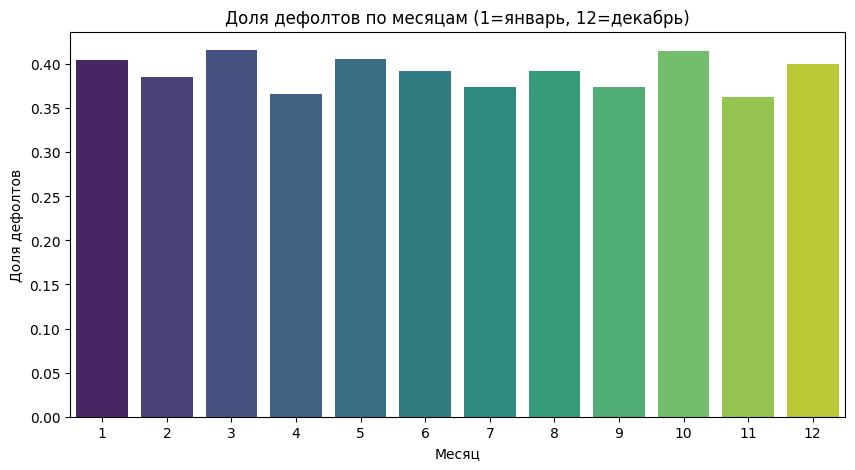

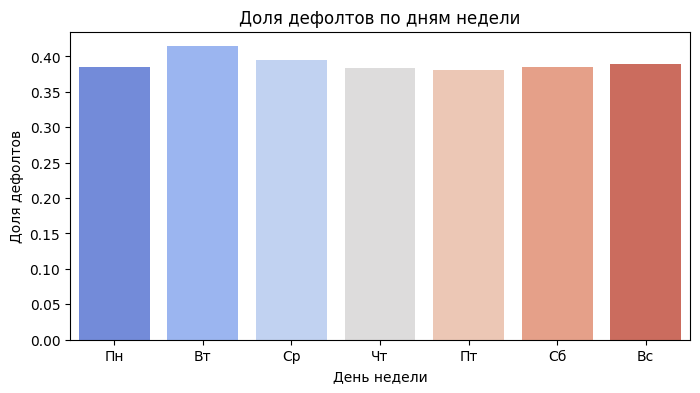

Дефолты в будни (0) и выходные (1): [0.39187913 0.38710778]


In [309]:
# Временной анализ

# Месяцы
monthly_def = data.groupby('order_month')['default_flag'].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_def, x='order_month', y='default_flag', palette='viridis')
plt.title('Доля дефолтов по месяцам (1=январь, 12=декабрь)')
plt.xlabel('Месяц')
plt.ylabel('Доля дефолтов')
plt.show()

# Дни недели
dow_def = data.groupby('order_dayofweek')['default_flag'].mean().reset_index()
dow_def['day_name'] = dow_def['order_dayofweek'].map({
    0:'Пн',1:'Вт',2:'Ср',3:'Чт',4:'Пт',5:'Сб',6:'Вс'
})
plt.figure(figsize=(8,4))
sns.barplot(data=dow_def, x='day_name', y='default_flag', palette='coolwarm')
plt.title('Доля дефолтов по дням недели')
plt.xlabel('День недели')
plt.ylabel('Доля дефолтов')
plt.show()

# Выходные vs будни
weekend_def = data.groupby('is_weekend')['default_flag'].mean()
print("Дефолты в будни (0) и выходные (1):", weekend_def.values)

`Доля дефолта колеблется от ~0.37 до ~0.42.` Нет выраженного линейного тренда. Небольшой пик наблюдается в марте (3) и октябре (10). Это может быть связано с сезонными финансовыми нагрузками (налоги, праздники  и тд), Но разница с остальными показателями отличается примерно на 5 процентов , без внешних источников тяжело будет найти закономерность.  в случае если признак будет  показывать или влиять на качество модели его можно будет убрать 

`По дням недели различия минимальны:` все значения в узком диапазоне 0.38–0.40. Вторник показывает чуть более высокую долю (0.40), но разница статистически незначима. Это говорит о том, что день покупки не оказывает заметного влияния на вероятность дефолта. Это признак можно иключить 

`По признаку выходного или рабочего дня различия минимальны` Это подтверждает, что выходной день покупки не является полезным предиктором. Это признак можно иключить 

### 4.2. Cоздание новых признаков

Для повышения качества модели необходимо создать новые признаки, отражающие финансовую нагрузку и взаимодействие ключевых факторов. 

`purchase_to_income` – доля стоимости покупки в месячном доходе. Высокое значение означает, что клиент тратит значительную часть заработка на BNPL-транзакцию, что увеличивает риск неплатежа при снижении доходов или непредвиденных расходах.

`install_to_income` – доля одного ежемесячного взноса в доходе. Более детальный показатель, чем общая сумма покупки, так как учитывает количество рассрочек. Чем выше эта доля, тем сильнее платежи давят на бюджет клиента.

`debt_to_credit` – отношение предполагаемого ежемесячного долга (DTI × доход) к кредитному рейтингу. Объединяет информацию о долговой нагрузке и качестве кредитной истории: у клиента с высоким DTI и низким кредитным рейтингом этот показатель резко возрастёт, сигнализируя о крайне высоком 

`delay_times_missed` – произведение дней задержки платежа на число пропусков. Позволяет модели улавливать нелинейное накопление риска: клиент с большим числом пропусков и длительными задержками гораздо опаснее, чем клиент с одним из этих признаков по отдельности.


In [310]:
#  1. Создание новых  признаков для анализа 
# 1.1  Отношение суммы к доходу . Высокое значение может  указывать на риск
data['purchase_to_income']=  data['purchase_amount'] / data['monthly_income']
# 1.2 размер одного платежа к доходу 
data['install_to_income']= (data['purchase_amount'] / data['bnpl_installments']) / data['monthly_income']
# 1.3 Отношение долга к кредитному рейтингу
data['debt_to_credit'] = data['debt_to_income_ratio'] * data['monthly_income'] / data['credit_score'].replace(0, 1)
# При необходимости бесконечные значения заменить на NaN и заполнить нулем
data['debt_to_credit'] = data['debt_to_credit'].replace([float('inf'), -float('inf')], float('nan')).fillna(0)

# 2. Взаимодействия (cross features)
# 2.1. repayment_delay_days * missed_payments
data['delay_times_missed'] = data['repayment_delay_days'] * data['missed_payments']
data['income_to_credit'] = data['monthly_income'] / (data['credit_score'] + 1)



### 4.3. Очистка неинформативных данных  и кодирование признаков 

#### СТатистические тесты для улавливания корреляции между выбранными категориальными признаками и целевой переменной

1. Критерий χ² (хи-квадрат) для таблиц сопряжённости выбранных призаков и целевой переменной 

Применение: проверка независимости двух признаков.

Нулевая гипотеза H₀: Страна/категория товара  и факт дефолта независимы.

Альтернативная гипотеза H₁: Между страной/категорией товара  и дефолтом существует статистически значимая связь.

In [311]:
# Создаём таблицу сопряжённости
table = pd.crosstab(data['location'], data['default_flag'])

# Выполняем тест
chi2, p, dof, expected = chi2_contingency(table)

print("Хи-квадрат тест: location vs default_flag")
print(f"Статистика χ² = {chi2:.4f}")
print(f"p-value = {p:.4f}")
if p < 0.05:
    print("Вывод: отвергаем H₀ → Между признаком и дефолтом ЕСТЬ статистически значимая связь.")
else:
    print("Вывод: нет оснований отвергнуть H₀ → Связь статистически НЕЗНАЧИМА.")


Хи-квадрат тест: location vs default_flag
Статистика χ² = 2.1343
p-value = 0.8303
Вывод: нет оснований отвергнуть H₀ → Связь статистически НЕЗНАЧИМА.


In [312]:
# Создаём таблицу сопряжённости
table = pd.crosstab(data['product_category'], data['default_flag'])

# Выполняем тест
chi2, p, dof, expected = chi2_contingency(table)

print("Хи-квадрат тест: product_category vs default_flag")
print(f"Статистика χ² = {chi2:.4f}")
print(f"p-value = {p:.4f}")

if p < 0.05:
    print("Вывод: отвергаем H₀ → Между признаком и дефолтом ЕСТЬ статистически значимая связь.")
else:
    print("Вывод: нет оснований отвергнуть H₀ → Связь статистически НЕЗНАЧИМА.")

Хи-квадрат тест: product_category vs default_flag
Статистика χ² = 6.4449
p-value = 0.1683
Вывод: нет оснований отвергнуть H₀ → Связь статистически НЕЗНАЧИМА.


In [313]:
from scipy.stats import mannwhitneyu, pointbiserialr

# список числовых признаков (без default_flag)
numeric_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features.remove('default_flag')  # убираем целевую переменную

results = []

for col in numeric_features:
    # разделяем данные по default_flag
    group0 = data.loc[data['default_flag'] == 0, col].dropna()
    group1 = data.loc[data['default_flag'] == 1, col].dropna()
    
    # U-тест Манна–Уитни
    u_stat, u_p = mannwhitneyu(group0, group1, alternative='two-sided')
    
    # точечно-бисериальная корреляция
    corr, pb_p = pointbiserialr(data['default_flag'], data[col])
    
    results.append({
        'feature': col,
        'u_pvalue': u_p,
        'pb_corr': corr,
        'pb_pvalue': pb_p,
        'significant_u': u_p < 0.05,
        'significant_pb': pb_p < 0.05
    })

# преобразуем в DataFrame для удобного просмотра
res_df = pd.DataFrame(results).sort_values('pb_pvalue')

# выводим признаки, прошедшие оба теста
selected = res_df[(res_df['significant_u']) & (res_df['significant_pb'])]
print("Признаки, статистически значимые по обоим критериям:")
print(selected[['feature', 'u_pvalue', 'pb_corr', 'pb_pvalue']])

# выводим все результаты 
res_df

Признаки, статистически значимые по обоим критериям:
                 feature       u_pvalue   pb_corr      pb_pvalue
9             risk_score   0.000000e+00  0.399379   0.000000e+00
2           credit_score  1.846109e-208 -0.324238  8.123492e-252
13    delay_times_missed  1.257802e-184  0.318342  2.548606e-242
5   repayment_delay_days  7.220107e-165  0.283209  4.624726e-190
1         monthly_income  6.614050e-134 -0.274163  9.057942e-178
6        missed_payments  5.870708e-136  0.272267  2.983831e-175
14      income_to_credit   2.020175e-89 -0.206079   1.295842e-99
8   debt_to_income_ratio  2.695755e-105  0.172947   2.832691e-70
10    purchase_to_income  2.695755e-105  0.172947   2.832691e-70
12        debt_to_credit   4.504405e-61  0.129317   8.017955e-40
11     install_to_income   2.543987e-60  0.123967   1.036282e-36
3        purchase_amount   6.115498e-32 -0.097912   1.836964e-23
0                    age   1.458144e-14 -0.075702   1.260226e-14


,feature,u_pvalue,pb_corr,pb_pvalue,significant_u,significant_pb
9,risk_score,0.000000e+00,0.399379,0.000000e+00,True,True
2,credit_score,1.846109e-208,-0.324238,8.123492e-252,True,True
13,delay_times_missed,1.257802e-184,0.318342,2.548606e-242,True,True
5,repayment_delay_days,7.220107e-165,0.283209,4.624726e-190,True,True
1,monthly_income,6.614050e-134,-0.274163,9.057942e-178,True,True
6,missed_payments,5.870708e-136,0.272267,2.983831e-175,True,True
14,income_to_credit,2.020175e-89,-0.206079,1.295842e-99,True,True
8,debt_to_income_ratio,2.695755e-105,0.172947,2.832691e-70,True,True
10,purchase_to_income,2.695755e-105,0.172947,2.832691e-70,True,True
12,debt_to_credit,4.504405e-61,0.129317,8.017955e-40,True,True


Вывод: 

При проведении статистических тестов было принято решение об удалении признаков  локации и категории продукта так как они не несут полезной информации для итоговой модели 

Так же подтвердились гипотезы о  признаках `bnpl_installments` и `app_usage_frequency`  и признак `года и месяца продажи`  -  они не вошли в таблицу с статистически значимыми признаками

#### удаляем признаки 

In [314]:
# удаляем неинофрмативные признаки по анализу выше и признаки 
# которые могут имень в себе данный для утечки

features_to_drop= ['is_weekend', 'order_dayofweek','customer_segment',
                   'bnpl_installments', 'app_usage_frequency', 'risk_score', 
                   'debt_to_income_ratio', 'location', 'product_category', 'order_year', 'order_month' ]

data= data.drop(features_to_drop, axis=1)


In [315]:
# Кодирование признаков 
data_encoded = pd.get_dummies(data, drop_first=True)


Топ-15 корреляций с default_flag (по модулю):
credit_score                    -0.324238
delay_times_missed               0.318342
repayment_delay_days             0.283209
monthly_income                  -0.274163
missed_payments                  0.272267
income_to_credit                -0.206079
purchase_to_income               0.172947
employment_type_Self-Employed   -0.150265
debt_to_credit                   0.129317
install_to_income                0.123967
employment_type_Unemployed       0.115157
employment_type_Student          0.110884
purchase_amount                 -0.097912
age                             -0.075702
Name: default_flag, dtype: float64

Пары с корреляцией |r|>0.95:
('credit_score', 'monthly_income', 0.9609889650370482)
('income_to_credit', 'monthly_income', 0.955493861217568)


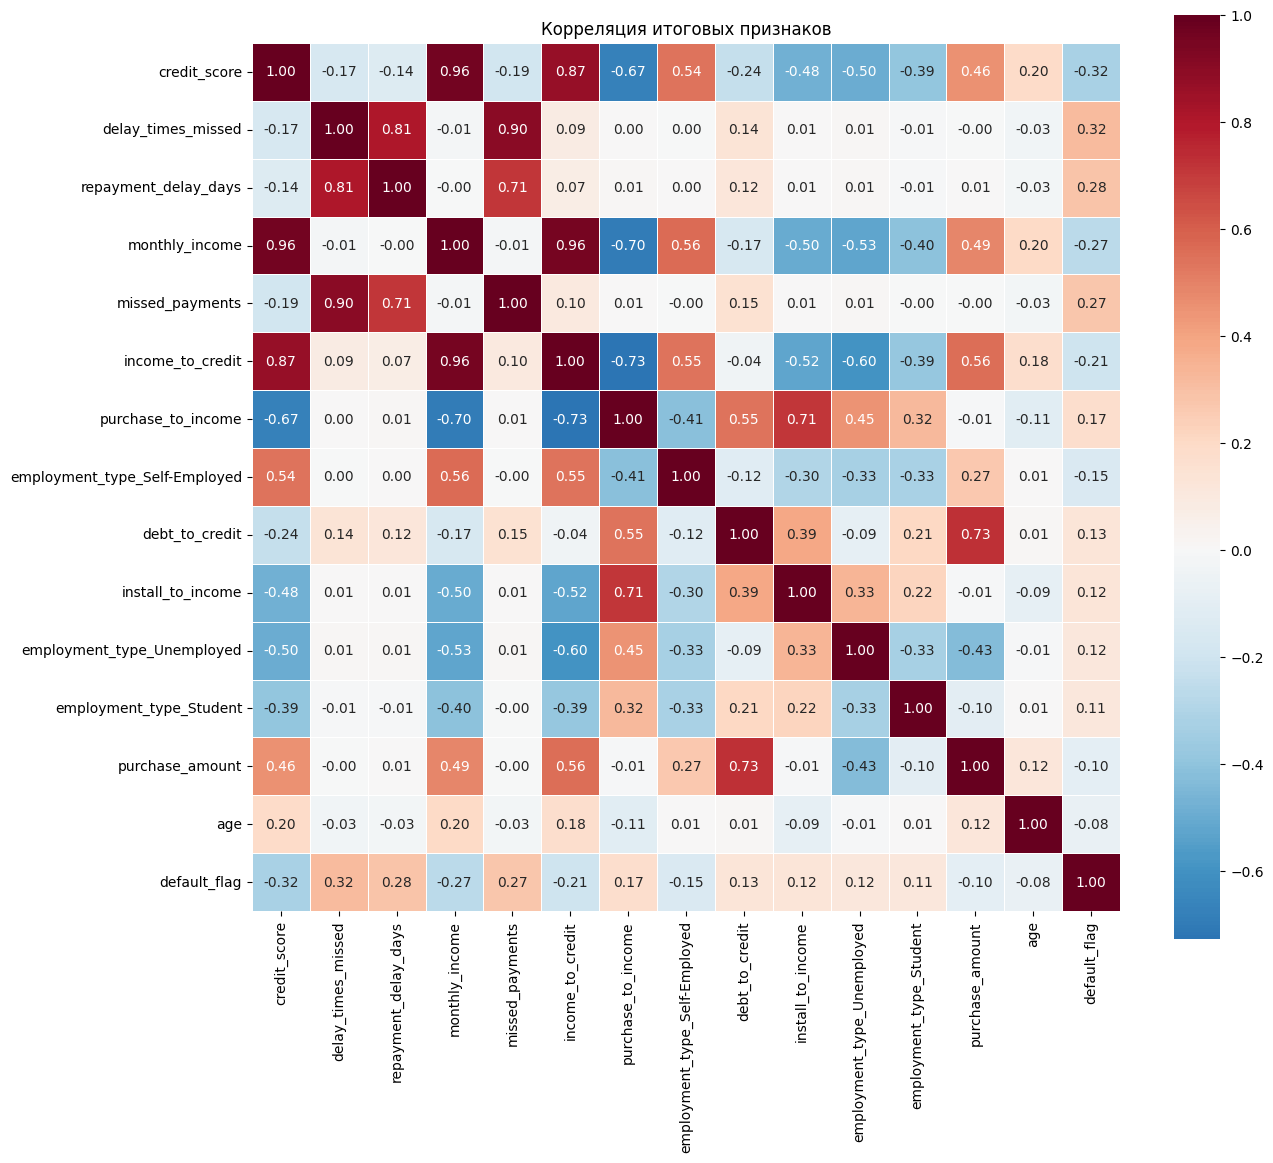

In [316]:
# проодим повторную корр данных
corr_matrix_final = data_encoded.corr()

# Корреляция с целевой переменной
target_corr_final = corr_matrix_final['default_flag'].drop('default_flag').sort_values(key=lambda x: x.abs(), ascending=False)
print("Топ-15 корреляций с default_flag (по модулю):")
print(target_corr_final.head(15))

# Поиск пар с очень высокой корреляцией >0.95
upper_tri = corr_matrix_final.where(np.triu(np.ones(corr_matrix_final.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col]) 
                   for col in upper_tri.columns 
                   for row in upper_tri.index 
                   if abs(upper_tri.loc[row, col]) > 0.95]
print("\nПары с корреляцией |r|>0.95:")
for pair in high_corr_pairs:
    print(pair)

# При желании можно построить heatmap для наиболее значимых признаков
import seaborn as sns
top_features = target_corr_final.head(20).index.tolist()
plt.figure(figsize=(14,12))
sns.heatmap(data_encoded[top_features + ['default_flag']].corr(), 
            annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Корреляция итоговых признаков')
plt.show()


По сравнению с исходным анализом картина стала более полной:

Новые признаки работают: `risk_times_missed и delay_times_missed` сразу вышли в топ, обогнав своих «прородителей» (repayment_delay_days и missed_payments) по силе связи с дефолтом. Это подтверждает, что взаимодействие факторов (риск × пропуски) важнее, чем каждый по отдельности.

`credit_income` также показал хорошую отрицательную корреляцию (-0.30), что говорит о полезности этого комбинированного показателя платёжеспособности.

Финансовая нагрузка: `purchase_to_income, debt_to_credit и install_to_income` вошли в топ-15, подтверждая гипотезу о важности этих показателей.

Категориальные признаки проявились: `employment_type_Self-Employed` имеет заметную отрицательную корреляцию (самозанятые реже становятся дефолтниками), а `категории Unemployed и Student` – ожидаемо положительные.

Признаки `credit_score и monthly_income (0.96) `, признаки имеют высокую коллериальность. Хотя оба интуитивно важны, для линейной модели лучше оставить только один, чтобы избежать проблем. Учитывая, что credit_score имеет более сильную связь с целевым признаком (-0.32 против -0.27), можно оставить credit_score, а monthly_income исключить. Однако monthly_income нужен для интерпретации в бизнес-контексте, поэтому его лучше оставить и использовать регуляризацию (L1/L2) в логистической регрессии, которая сама «отожмёт» избыточный признак.
risk_times_missed и missed_payments (0.95). При построении модели я опробую разные варианты и при необхоимости уберу один из признаков 

Вывод: Новые признаки значимы и должны остаться в модели.

## Глава 5. Построение моделей 

In [317]:
# разеляем выборку на тренирововчную и тестовую
X= data_encoded.drop('default_flag', axis=1)
y= data_encoded['default_flag']


In [318]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state = 42, test_size = 0.2)
# проверяем распределение 
train_dist = y_train.value_counts(normalize=True) * 100
test_dist = y_test.value_counts(normalize=True) * 100

print("Train (%):")
print(train_dist)
print("\nTest (%):")
print(test_dist)



Train (%):
default_flag
0    60.947318
1    39.052682
Name: proportion, dtype: float64

Test (%):
default_flag
0    60.947318
1    39.052682
Name: proportion, dtype: float64


In [319]:
# Маштабирование признаков 
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

### Построение моделей 

In [320]:
# Определяем модели
models = {
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

# Стратифицированная кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train_scaler, y_train,
                             cv=skf, scoring='average_precision', n_jobs=-1)
    results[name] = scores
    print(f"{name}: Mean PR-AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")

LogisticRegression: Mean PR-AUC = 0.6470 (+/- 0.0112)
RandomForest: Mean PR-AUC = 0.6549 (+/- 0.0153)
GradientBoosting: Mean PR-AUC = 0.6772 (+/- 0.0119)
XGBoost: Mean PR-AUC = 0.6492 (+/- 0.0149)


In [325]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# param_dist = {
#     'n_estimators': randint(100, 500),
#     'max_depth': randint(3, 10),
#     'learning_rate': uniform(0.01, 0.2),
#     'subsample': uniform(0.6, 0.4),
#     'colsample_bytree': uniform(0.6, 0.4),
#     'gamma': uniform(0, 0.3),
#     'reg_alpha': uniform(0, 1),
#     'reg_lambda': uniform(1, 2),
#     'scale_pos_weight': [1, 2, 3]
# }
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

xgb_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,               # количество случайных комбинаций
    cv=3,                    # кросс-валидация
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)



random_search.fit(X_train_scaler, y_train)
print("Best params:", random_search.best_params_)
print("Best PR-AUC:", random_search.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5, 'learning_rate': 0.05}
Best PR-AUC: 0.5588786963894652


## Глава 6.  Интерпретация модели

In [ ]:
best_model= GradientBoosting(subsample=1., n_estimators=  100,min_samples_split= 2, min_samples_leaf= 1, max_depth= 3, learning_rate= 0.05)

# Предсказания и вероятности
y_pred = best_model.predict(X_test_scaler)
y_proba = best_model.predict_proba(X_test_scaler)[:, 1]

# Основные метрики
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# PR-кривая
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
plt.subplot(1, 3, 2)
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()

# Калибровочная кривая
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.subplot(1, 3, 3)
plt.plot(prob_pred, prob_true, marker='o', label='XGBoost')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()

plt.tight_layout()
plt.savefig('evaluation_plots.png', dpi=150)
plt.show()

In [ ]:
# Важность признаков для XGBoost или деревьев
feature_names = X.columns.tolist()
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title('Feature Importances (XGBoost)')
plt.barh(range(len(indices[:20])), importances[indices[:20]], align='center')
plt.yticks(range(len(indices[:20])), [feature_names[i] for i in indices[:20]])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

## Улучшение качества

Построить калибровочную кривую (reliability curve) – важна для вероятностной интерпретации.

Матрицу ошибок и кривую ROC – стандартная подача результатов.

Сравнить модели в табличной форме (Mean AUC, Std AUC).

In [ ]:
# Простой ансамбль (голосование) из нескольких моделей
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')),
        ('rf', RandomForestClassifier(random_state=42, n_jobs=-1)),
        ('xgb', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
    ],
    voting='soft'  # вероятностное голосование
)

voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)
y_proba_vote = voting_clf.predict_proba(X_test)[:, 1]

print("Voting Ensemble Test AUC:", roc_auc_score(y_test, y_proba_vote))
print(classification_report(y_test, y_pred_vote))

## Практическая реализация

Разделить данные на train/test (стратифицированно) до любой предобработки, чтобы избежать утечки данных.

Паплайн – использовать ColumnTransformer и Pipeline из sklearn для чистоты кода.

Экспорт прототипа – сохранить модель (joblib) и написать простой API (Flask/FastAPI) для демонстрации.

In [ ]:
# # Сохраняем лучшую модель и scaler (если нужен)
# joblib.dump(best_model, 'best_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')
# print("Model and scaler saved.")

## Вывод и бизнес рекомендация

**Значение для моделирования:**

Выявленный дисбаланс классов (около 39% дефолтов) требует обязательного использования стратифицированного разбиения и специальных метрик (PR-AUC, F1-score). Наличие выбросов по доходу, длительности просрочки и количеству пропусков не критично для древовидных моделей, но для линейных методов потребует масштабирования или ограничения экстремальных значений. Такие признаки, как credit_score, monthly_income, repayment_delay_days и risk_score, уже на этапе описательной статистики демонстрируют сильную дифференцирующую способность и будут играть ключевую роль в предиктивной модели.